<a href="https://colab.research.google.com/github/rsanchezgarc/AI-ML-analytics-IE/blob/main/notebooks/7_generative_models/AdversarialAttack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original prediction: Egyptian cat

Top-5 before attack:
1. Egyptian cat (0.3914)
2. tiger cat (0.3861)
3. tabby (0.2176)
4. lynx (0.0045)
5. Persian cat (0.0002)

Target class: sports car

Adversarial prediction: sports car

Top-5 after attack:
1. sports car (0.5978)
2. racer (0.1271)
3. red fox (0.0344)
4. plastic bag (0.0159)
5. car wheel (0.0116)


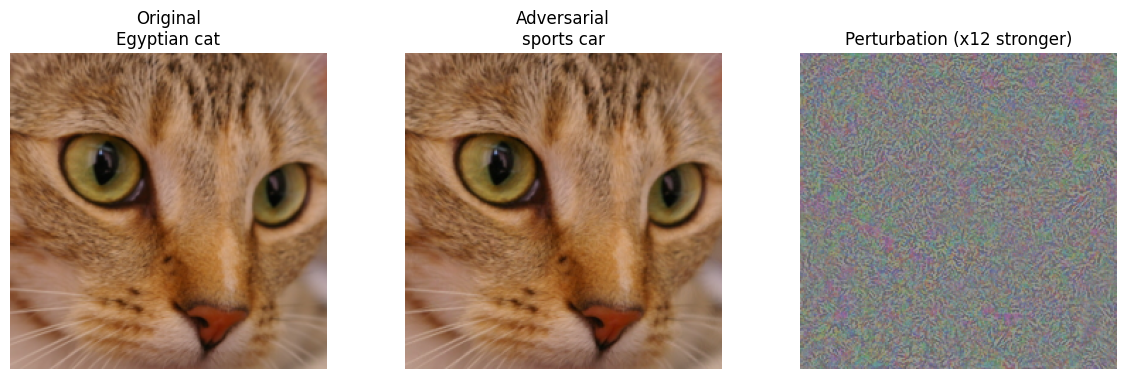

In [6]:
import torch
import torch.nn.functional as F
from torchvision import models
from torchvision.models import ResNet18_Weights, ResNet50_Weights
from PIL import Image
from skimage.data import cat
import matplotlib.pyplot as plt

# -------------------------
# 1) Model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights).to(device)
model.eval()

preprocess = weights.transforms()
categories = weights.meta["categories"]

# -------------------------
# 2) Image
# -------------------------
img_pil = Image.fromarray(cat())
x0 = preprocess(img_pil).unsqueeze(0).to(device)

mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

x_min_norm = (0.0 - mean) / std
x_max_norm = (1.0 - mean) / std

def denormalize(x):
    return torch.clamp(x * std + mean, 0, 1)

def topk_str(logits, k=5):
    probs = torch.softmax(logits, dim=1)
    vals, idxs = torch.topk(probs, k)
    lines = []
    for i in range(k):
        idx = idxs[0, i].item()
        lines.append(f"{i+1}. {categories[idx]} ({vals[0, i].item():.4f})")
    return "\n".join(lines)

def find_target(label_text):
    label_text = label_text.lower()
    matches = [i for i, c in enumerate(categories) if label_text in c.lower()]
    if not matches:
        raise ValueError(f"No ImageNet label contains: {label_text}")
    return matches[0], categories[matches[0]]

# Choose a target that exists in ImageNet.
# Examples to try:
#   "sports car"
#   "convertible"
#   "pickup"
#   "jeep"
#   "scuba diver"
target_idx, target_name = find_target("sports car")
target = torch.tensor([target_idx], device=device)

# -------------------------
# 3) Check original prediction
# -------------------------
with torch.no_grad():
    logits0 = model(x0)
    pred0 = logits0.argmax(dim=1).item()

print("Original prediction:", categories[pred0])
print("\nTop-5 before attack:")
print(topk_str(logits0, k=5))
print("\nTarget class:", target_name)

# -------------------------
# 4) Targeted PGD attack
#    minimize CE(logits, target)
# -------------------------
epsilon = 12.0 / 255.0   # maximum size of the perturbation
alpha = 1.0 / 255.0      # step size
steps = 10               # more steps = stronger

x_adv = x0.clone().detach()

for step in range(steps):
    x_adv.requires_grad_(True)

    logits = model(x_adv)
    loss = F.cross_entropy(logits, target)

    model.zero_grad(set_to_none=True)
    if x_adv.grad is not None:
        x_adv.grad.zero_()
    loss.backward()

    with torch.no_grad():
        # targeted attack: go in direction that REDUCES target loss
        x_adv = x_adv - alpha * x_adv.grad.sign()

        # project back into epsilon-ball around original x0
        delta = torch.clamp(x_adv - x0, min=-epsilon, max=epsilon)
        x_adv = x0 + delta

        # keep valid normalized image range
        x_adv = torch.max(torch.min(x_adv, x_max_norm), x_min_norm)

# -------------------------
# 5) Final prediction
# -------------------------
with torch.no_grad():
    logits_adv = model(x_adv)
    pred_adv = logits_adv.argmax(dim=1).item()

print("\nAdversarial prediction:", categories[pred_adv])
print("\nTop-5 after attack:")
print(topk_str(logits_adv, k=5))

# -------------------------
# 6) Show images
# -------------------------
x_img = denormalize(x0).detach().cpu()[0].permute(1, 2, 0)
x_adv_img = denormalize(x_adv).detach().cpu()[0].permute(1, 2, 0)
pert = x_adv_img - x_img
pert_vis = torch.clamp(pert * 12 + 0.5, 0, 1)   # amplified for display

plt.figure(figsize=(12, 3.8))

plt.subplot(1, 3, 1)
plt.imshow(x_img)
plt.title(f"Original\n{categories[pred0]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_adv_img)
plt.title(f"Adversarial\n{categories[pred_adv]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pert_vis)
plt.title("Perturbation (x12 stronger)")
plt.axis("off")

plt.tight_layout()
plt.show()
plt.close('all')

Note that the adversarial example is model specific. If we use another different, its impact should be minor.

In [7]:
weights = ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights).to(device)
model.eval()

with torch.no_grad():
    logits_adv = model(x_adv)
    pred_adv = logits_adv.argmax(dim=1).item()

print("\nAdversarial prediction:", categories[pred_adv])
print("\nTop-5 after attack:")
print(topk_str(logits_adv, k=5))


Adversarial prediction: Egyptian cat

Top-5 after attack:
1. Egyptian cat (0.2499)
2. tabby (0.0954)
3. tiger cat (0.0792)
4. lynx (0.0054)
5. remote control (0.0019)
